In [8]:
# ============================================================
# BLOCK 1: Import required libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    AdditiveAttention,
    Concatenate
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
# ============================================================
# BLOCK 2: Create toy Seq2Seq dataset
# ============================================================

PAD = 0
START = 1
END = 2

DIGIT_OFFSET = 3
VOCAB_SIZE = 13
MAX_SEQ_LEN = 8

def generate_seq2seq_data(num_samples=12000):

    encoder_inputs = []
    decoder_inputs = []
    decoder_outputs = []

    for _ in range(num_samples):

        length = np.random.randint(3, MAX_SEQ_LEN + 1)
        digits = np.random.randint(0, 10, size=length)

        source = digits + DIGIT_OFFSET
        target = source[::-1]

        enc = np.zeros(MAX_SEQ_LEN, dtype="int32")
        dec_in = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")
        dec_out = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")

        enc[:length] = source

        dec_in[0] = START
        dec_in[1:length + 1] = target

        dec_out[:length] = target
        dec_out[length] = END

        encoder_inputs.append(enc)
        decoder_inputs.append(dec_in)
        decoder_outputs.append(dec_out)

    return (
        np.array(encoder_inputs),
        np.array(decoder_inputs),
        np.array(decoder_outputs)
    )

encoder_input_data, decoder_input_data, decoder_output_data = generate_seq2seq_data()

print("Encoder input shape:", encoder_input_data.shape)
print("Decoder input shape:", decoder_input_data.shape)
print("Decoder output shape:", decoder_output_data.shape)

Encoder input shape: (12000, 8)
Decoder input shape: (12000, 9)
Decoder output shape: (12000, 9)


In [6]:
# ============================================================
# BLOCK 3: Helper function to display token IDs
# as readable text
# ============================================================

def token_to_text(tokens):

    text_tokens = []

    for token in tokens:

        token = int(token)

        if token == PAD:
            continue

        elif token == START:
            text_tokens.append("<start>")

        elif token == END:
            text_tokens.append("<end>")

        else:
            text_tokens.append(str(token - DIGIT_OFFSET))

    return text_tokens

In [9]:
# ============================================================
# BLOCK 4: Build Seq2Seq model with additive attention
# ============================================================

EMBED_DIM = 64
LATENT_DIM = 128

encoder_inputs = Input(
    shape=(MAX_SEQ_LEN,),
    name="encoder_inputs"
)

encoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    mask_zero=True,
    name="encoder_embedding"
)

encoder_embedded = encoder_embedding(encoder_inputs)

encoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedded)

decoder_inputs = Input(
    shape=(MAX_SEQ_LEN + 1,),
    name="decoder_inputs"
)

decoder_embedding = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    mask_zero=True,
    name="decoder_embedding"
)

decoder_embedded = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded,
    initial_state=[state_h, state_c]
)

attention_layer = AdditiveAttention(
    name="attention_layer"
)

context_vectors, attention_scores = attention_layer(
    [decoder_outputs, encoder_outputs],
    return_attention_scores=True
)

combined_outputs = Concatenate(
    name="concat_context"
)(
    [decoder_outputs, context_vectors]
)

output_layer = Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="output_layer"
)

final_outputs = output_layer(combined_outputs)

seq2seq_attention_model = Model(
    [encoder_inputs, decoder_inputs],
    final_outputs
)

attention_visualization_model = Model(
    [encoder_inputs, decoder_inputs],
    [final_outputs, attention_scores]
)

seq2seq_attention_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 8, 64)     │        832 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 8)         │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 9, 64)     │        832 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 8, 128),  │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_2[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 9, 128),  │     98,816 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, 9, 128),  │        128 │ decoder_lstm[0][… │
│ (AdditiveAttention) │ (None, 9, 8)]     │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 9, 256)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 9, 13)     │      3,341 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 202,765 (792.05 KB)

 Trainable params: 202,765 (792.05 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# BLOCK 5: Train the Seq2Seq attention model
# ============================================================

history = seq2seq_attention_model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_output_data,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.3922 - loss: 1.6898 - val_accuracy: 0.5466 - val_loss: 1.1698
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7785 - loss: 0.6710 - val_accuracy: 0.9186 - val_loss: 0.3320
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9497 - loss: 0.2238 - val_accuracy: 0.9646 - val_loss: 0.1571
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9781 - loss: 0.1135 - val_accuracy: 0.9820 - val_loss: 0.0935
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9867 - loss: 0.0742 - val_accuracy: 0.9863 - val_loss: 0.0666
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9932 - loss: 0.0472 - val_accuracy: 0.9898 - val_loss: 0.0553
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9945 - loss: 0.0386 - val_accuracy: 0.9949 - val_loss: 0.0347
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9939 - loss: 0.0354 - val_

In [11]:
# ============================================================
# BLOCK 6: Test prediction from the trained model
# ============================================================

def predict_sequence(sample_index):

    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions = seq2seq_attention_model.predict(
        [enc, dec],
        verbose=0
    )

    predicted_tokens = np.argmax(
        predictions[0],
        axis=-1
    )

    print("Input sequence: ", token_to_text(enc[0]))

    print(
        "Expected output: ",
        token_to_text(decoder_output_data[sample_index])
    )

    print(
        "Predicted output: ",
        token_to_text(predicted_tokens)
    )

predict_sequence(0)
predict_sequence(1)
predict_sequence(2)

Input sequence:  ['6', '5', '5']
Expected output:  ['5', '5', '6', '<end>']
Predicted output:  ['5', '5', '6', '<end>', '<end>', '<end>', '<end>', '<end>', '<end>']
Input sequence:  ['4', '3', '5', '8', '9']
Expected output:  ['9', '8', '5', '3', '4', '<end>']
Predicted output:  ['9', '8', '5', '3', '4', '<end>', '<end>', '<end>', '<end>']
Input sequence:  ['6', '6', '7', '5', '3', '2', '2']
Expected output:  ['2', '2', '3', '5', '7', '6', '6', '<end>']
Predicted output:  ['2', '2', '3', '5', '7', '6', '6', '<end>', '<end>']


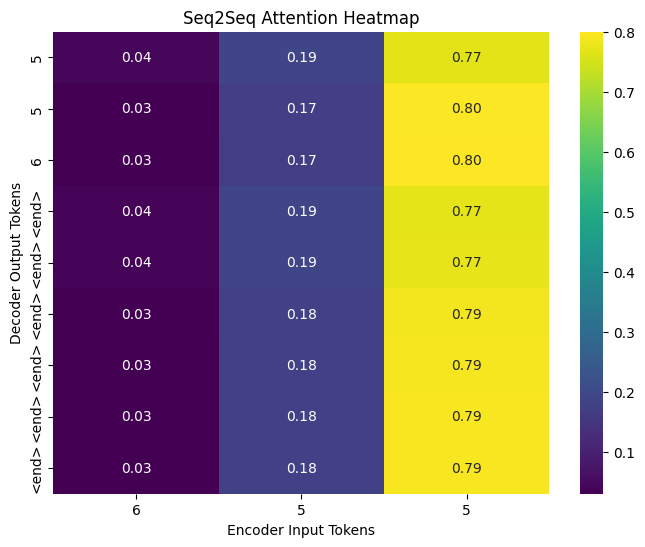

Input sequence:  ['6', '5', '5']
Predicted output:  ['5', '5', '6', '<end>', '<end>', '<end>', '<end>', '<end>', '<end>']


In [12]:
# ============================================================
# BLOCK 7: Visualize attention heatmap
# ============================================================

def plot_attention_heatmap(sample_index):

    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions, attention = attention_visualization_model.predict(
        [enc, dec],
        verbose=0
    )

    predicted_tokens = np.argmax(
        predictions[0],
        axis=-1
    )

    input_tokens = token_to_text(enc[0])
    output_tokens = token_to_text(predicted_tokens)

    input_len = len(input_tokens)
    output_len = len(output_tokens)

    attention_matrix = attention[0][:output_len, :input_len]

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        attention_matrix,
        xticklabels=input_tokens,
        yticklabels=output_tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f"
    )

    plt.xlabel("Encoder Input Tokens")
    plt.ylabel("Decoder Output Tokens")
    plt.title("Seq2Seq Attention Heatmap")

    plt.show()

    print("Input sequence: ", input_tokens)
    print("Predicted output: ", output_tokens)

plot_attention_heatmap(0)

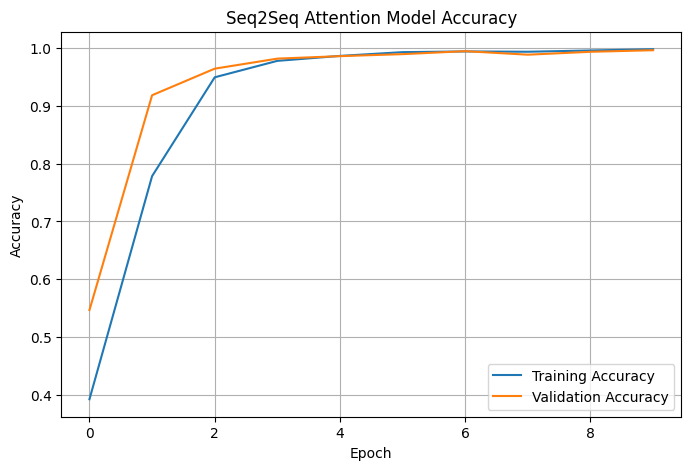

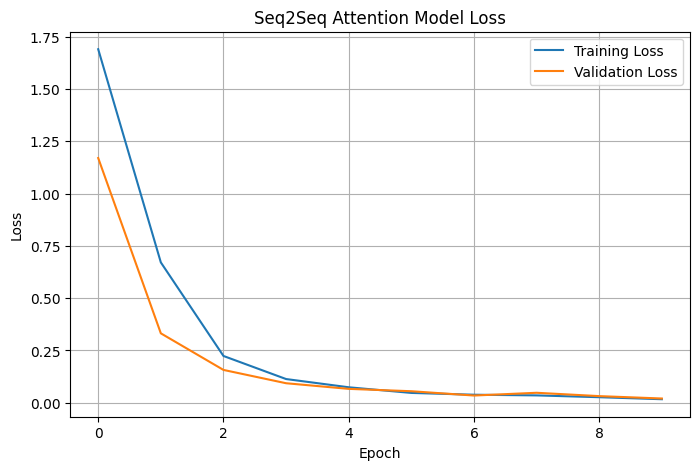

In [13]:
# ============================================================
# BLOCK 8: Plot training accuracy and loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Seq2Seq Attention Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Seq2Seq Attention Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()